<a href="https://colab.research.google.com/github/vdiscience/Artificial_Intelligence_Tranning/blob/main/ComputerVisionIntro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.PETS)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 02:48&lt;00:00]</div>

In [3]:
path.ls()

[Path('/root/.fastai/data/oxford-iiit-pet/annotations'), Path('/root/.fastai/data/oxford-iiit-pet/images')]

In [4]:
files = get_image_files(path/"images")
len(files)

7390

In [5]:
files[0],files[6]

(Path('/root/.fastai/data/oxford-iiit-pet/images/Sphynx_246.jpg'),
 Path('/root/.fastai/data/oxford-iiit-pet/images/Russian_Blue_83.jpg'))

In [6]:
def label_func(f): return f[0].isupper()

In [7]:
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

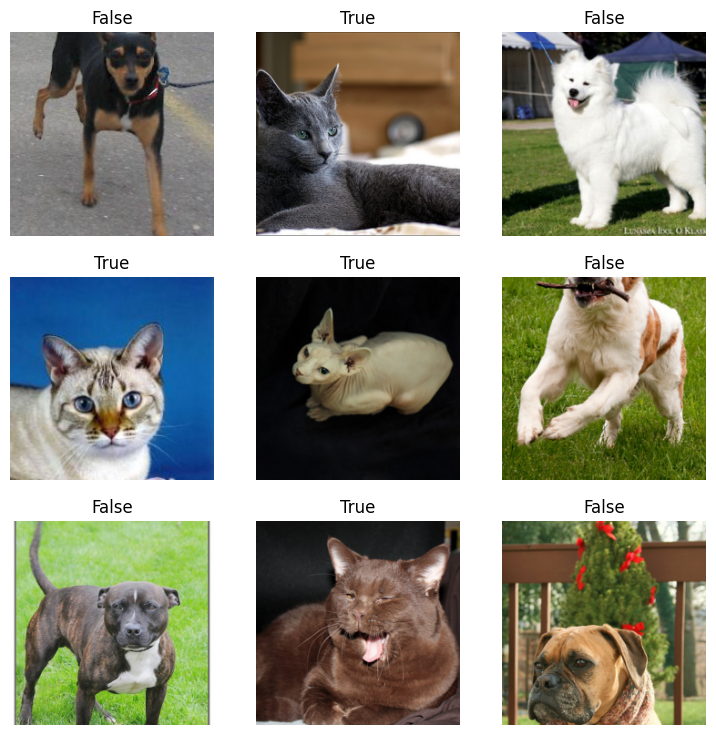

In [8]:
dls.show_batch()

In [9]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 171MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.144564,0.040064,0.012855,00:41


epoch,train_loss,valid_loss,error_rate,time
0,0.049069,0.018831,0.005413,00:39


In [10]:
learn.predict(files[0])

('True', tensor(1), tensor([0.0228, 0.9772]))

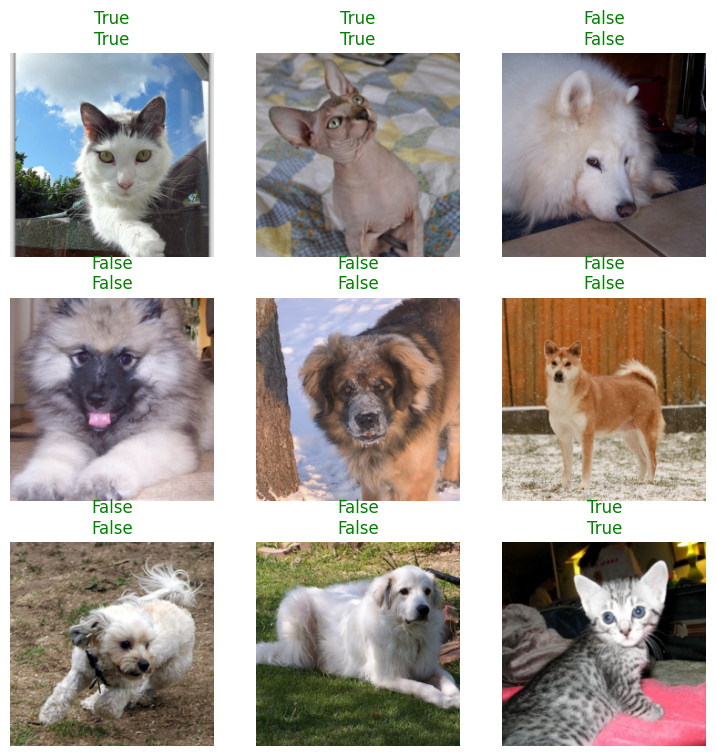

In [11]:
learn.show_results()

In [12]:
files[0].name

'Sphynx_246.jpg'

In [13]:
pat = r'^(.*)_\d+.jpg'

In [14]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(224))

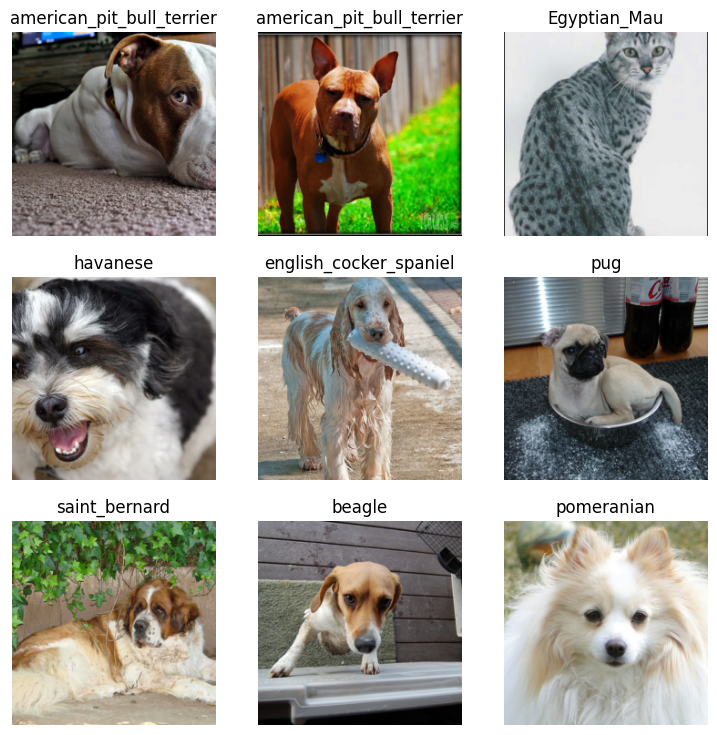

In [15]:
dls.show_batch()

In [16]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(460),
                                    batch_tfms=aug_transforms(size=224))

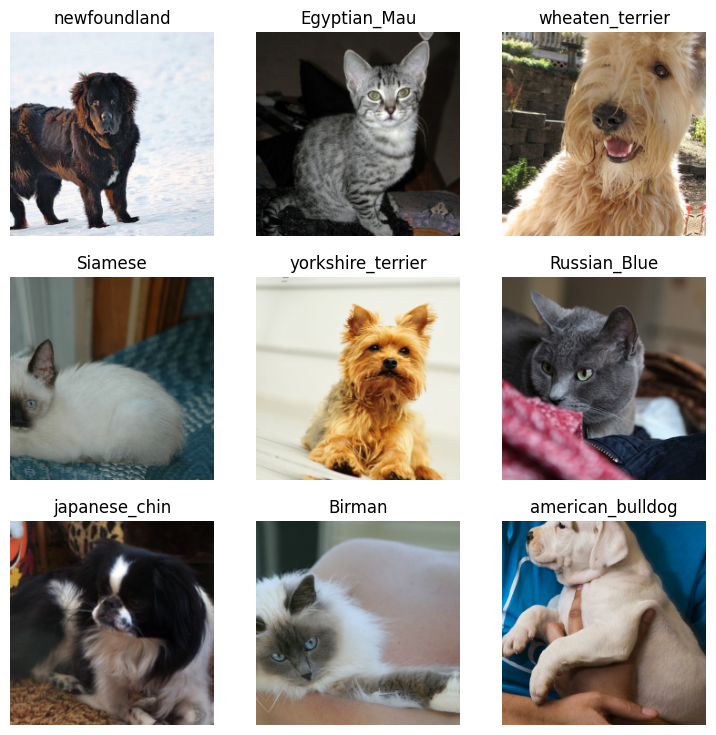

In [17]:
dls.show_batch()

In [18]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

<div></div>

SuggestedLRs(valley=0.0010000000474974513)

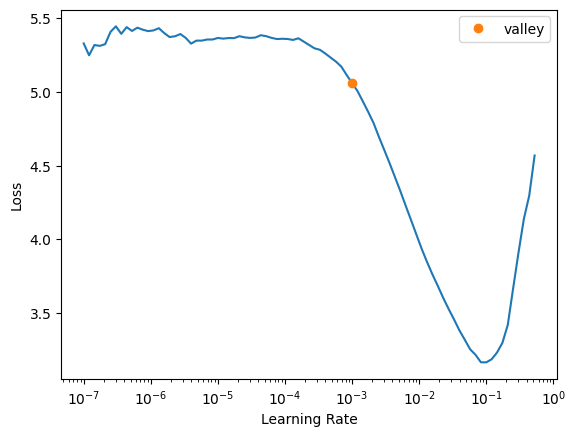

In [19]:
learn.lr_find()

In [ ]:
learn.fine_tune(2, 3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.259928,0.357194,0.117050,01:01


epoch,train_loss,valid_loss,error_rate,time


In [ ]:
learn.show_results()